# Space Weather Events Analysis

This project analyzes space weather events such as Solar Flares, High Speed Streams, and Geomagnetic Storms using Python and SQL.

The objective is to explore patterns in solar activity and identify trends across time such as yearly, monthly, and hourly distributions of events.

## Import Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Load Dataset

The dataset is loaded using pandas to begin the analysis.  
We also preview the first few rows to understand the structure of the dataset.

In [2]:
df = pd.read_csv('space_weather_unified.csv')
df.head()

,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,11-07-2023,2023,7,11,14
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,11-07-2023,2023,7,11,16
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,11-07-2023,2023,7,11,16
3,2023-07-11T17:51:00-FLR-001,Solar Flare,2023-07-11 17:51:00+00:00,2023-07-11 18:08:00+00:00,2023-07-11 18:16:00+00:00,M6.8,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,11-07-2023,2023,7,11,17
4,2023-07-11T19:20:00-FLR-001,Solar Flare,2023-07-11 19:20:00+00:00,2023-07-11 19:29:00+00:00,2023-07-11 19:39:00+00:00,M1.0,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,Simultaneous brightening south of AR3363.,NaN,NaN,NaN,11-07-2023,2023,7,11,19


## Dataset Structure

We first examine the structure of the dataset using `df.info()` to understand:

- Number of rows and columns
- Data types of each column
- Non-null values present in the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         1743 non-null   object 
 1   event_type       1743 non-null   object 
 2   begin_time       1743 non-null   object 
 3   peak_time        1599 non-null   object 
 4   end_time         1599 non-null   object 
 5   class_type       1640 non-null   object 
 6   source_location  1599 non-null   object 
 7   active_region    1552 non-null   float64
 8   instruments      1702 non-null   object 
 9   note             398 non-null    object 
 10  kp_index         41 non-null     float64
 11  observed_time    41 non-null     object 
 12  source           41 non-null     object 
 13  date             1743 non-null   object 
 14  year             1743 non-null   int64  
 15  month            1743 non-null   int64  
 16  day              1743 non-null   int64  
 17  hour          

## Missing Values Analysis

Before performing data cleaning, we check for missing values in the dataset.  
This helps identify columns that contain null values and require cleaning or removal.

In [4]:
df.isnull().sum()

event_id              0
event_type            0
begin_time            0
peak_time           144
end_time            144
class_type          103
source_location     144
active_region       191
instruments          41
note               1345
kp_index           1702
observed_time      1702
source             1702
date                  0
year                  0
month                 0
day                   0
hour                  0
dtype: int64

## Removing Irrelevant Columns

Some columns contain excessive missing values and are not useful for analysis.

The following columns were removed:

- note
- kp_index
- observed_time
- source

In [5]:
df = df.drop(columns = ['note','kp_index','observed_time','source'])

## Updated Dataset Structure

After removing unnecessary columns, we re-examine the dataset structure to confirm the changes and ensure that only relevant columns remain.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         1743 non-null   object 
 1   event_type       1743 non-null   object 
 2   begin_time       1743 non-null   object 
 3   peak_time        1599 non-null   object 
 4   end_time         1599 non-null   object 
 5   class_type       1640 non-null   object 
 6   source_location  1599 non-null   object 
 7   active_region    1552 non-null   float64
 8   instruments      1702 non-null   object 
 9   date             1743 non-null   object 
 10  year             1743 non-null   int64  
 11  month            1743 non-null   int64  
 12  day              1743 non-null   int64  
 13  hour             1743 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 190.8+ KB


## Data Type Conversion

To ensure accurate analysis, some columns were converted to appropriate data types:

- Time columns were converted to datetime format
- The active_region column was converted to integer type

In [7]:
df['begin_time'] = pd.to_datetime(df['begin_time'])
df['peak_time'] = pd.to_datetime(df['peak_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['active_region'] = df['active_region'].astype('Int64')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   event_id         1743 non-null   object             
 1   event_type       1743 non-null   object             
 2   begin_time       1743 non-null   datetime64[ns, UTC]
 3   peak_time        1599 non-null   datetime64[ns, UTC]
 4   end_time         1599 non-null   datetime64[ns, UTC]
 5   class_type       1640 non-null   object             
 6   source_location  1599 non-null   object             
 7   active_region    1552 non-null   Int64              
 8   instruments      1702 non-null   object             
 9   date             1743 non-null   object             
 10  year             1743 non-null   int64              
 11  month            1743 non-null   int64              
 12  day              1743 non-null   int64              
 13  hour             1

## Handling Missing Values

Missing values in certain columns were handled using appropriate replacements:

- Categorical columns were filled with 'Unknown'
- Numerical columns were filled with 0

In [9]:
df['class_type'] = df['class_type'].fillna('Unknown')
df['source_location'] = df['source_location'].fillna('Unknown')
df['active_region'] = df['active_region'].fillna(0)
df['instruments'] = df['instruments'].fillna('Unknown')

## Final Dataset Structure

After completing the cleaning process, we review the dataset structure again to confirm that all columns have appropriate data types and no critical missing values remain.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   event_id         1743 non-null   object             
 1   event_type       1743 non-null   object             
 2   begin_time       1743 non-null   datetime64[ns, UTC]
 3   peak_time        1599 non-null   datetime64[ns, UTC]
 4   end_time         1599 non-null   datetime64[ns, UTC]
 5   class_type       1743 non-null   object             
 6   source_location  1743 non-null   object             
 7   active_region    1743 non-null   Int64              
 8   instruments      1743 non-null   object             
 9   date             1743 non-null   object             
 10  year             1743 non-null   int64              
 11  month            1743 non-null   int64              
 12  day              1743 non-null   int64              
 13  hour             1

## Dataset Size

The shape of the dataset shows the total number of rows and columns present after cleaning.

In [11]:
df.shape

(1743, 14)

## Preview of Dataset

The first few rows of the dataset are displayed to verify that the data has been properly loaded and cleaned.

In [12]:
df.head()

,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,date,year,month,day,hour
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379,GOES-P: EXIS 1.0-8.0,11-07-2023,2023,7,11,14
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372,GOES-P: EXIS 1.0-8.0,11-07-2023,2023,7,11,16
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372,GOES-P: EXIS 1.0-8.0,11-07-2023,2023,7,11,16
3,2023-07-11T17:51:00-FLR-001,Solar Flare,2023-07-11 17:51:00+00:00,2023-07-11 18:08:00+00:00,2023-07-11 18:16:00+00:00,M6.8,N25E88,13372,GOES-P: EXIS 1.0-8.0,11-07-2023,2023,7,11,17
4,2023-07-11T19:20:00-FLR-001,Solar Flare,2023-07-11 19:20:00+00:00,2023-07-11 19:29:00+00:00,2023-07-11 19:39:00+00:00,M1.0,N25E88,13372,GOES-P: EXIS 1.0-8.0,11-07-2023,2023,7,11,19


## Preview of Dataset

The first few rows of the dataset are displayed to verify that the data has been properly loaded and cleaned.

In [13]:
df.describe()

,active_region,year,month,day,hour
count,1743.0,1743.000000,1743.000000,1743.000000,1743.000000
mean,12246.471601,2024.039013,6.629948,14.809524,11.562823
std,4301.029685,0.566652,3.313882,9.124813,6.940988
min,0.0,2023.000000,1.000000,1.000000,0.000000
25%,13561.0,2024.000000,4.000000,7.000000,6.000000
50%,13738.0,2024.000000,7.000000,14.000000,12.000000
75%,13878.0,2024.000000,9.000000,23.000000,18.000000
max,14136.0,2025.000000,12.000000,31.000000,23.000000


## Event Type Distribution

This analysis examines the frequency of different types of space weather events in the dataset.

The dataset mainly contains three event types:
- Solar Flare
- High Speed Stream
- Geomagnetic Storm

In [14]:
df['event_type'].value_counts()

event_type
Solar Flare          1599
High Speed Stream     103
Geomagnetic Storm      41
Name: count, dtype: int64

### Visualization of Event Types

A bar chart is used to visualize the distribution of different space weather events.
This helps identify which type of event occurs most frequently.

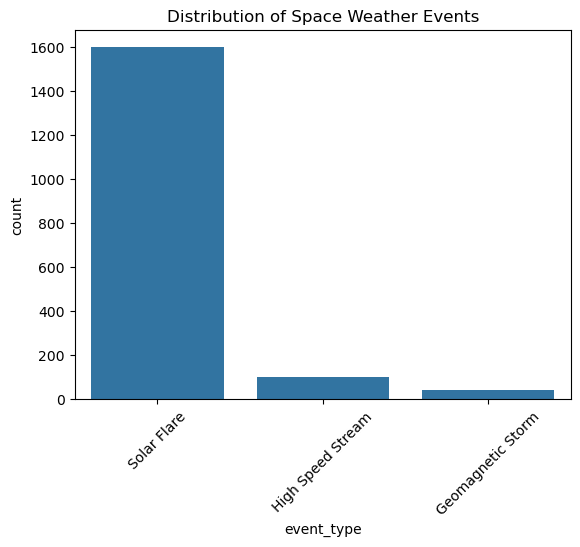

In [15]:
sns.countplot(x='event_type', data=df)
plt.title("Distribution of Space Weather Events")
plt.xticks(rotation=45)
plt.show()

## Year-wise Distribution of Events

To understand how solar activity varies over time, we analyze the number of events occurring in each year.

In [16]:
df.groupby('year')['event_type'].count()

year
2023     247
2024    1181
2025     315
Name: event_type, dtype: int64

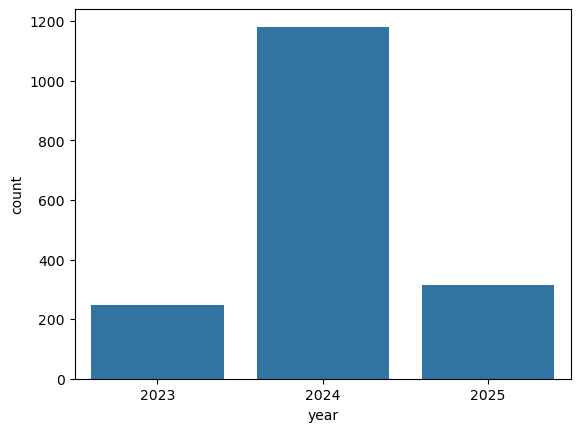

In [17]:
sns.countplot(x='year', data=df)
plt.show()

### Event Type Comparison by Year

This visualization shows how different event types are distributed across years.  
It helps compare solar flares, high-speed streams, and geomagnetic storms across time.

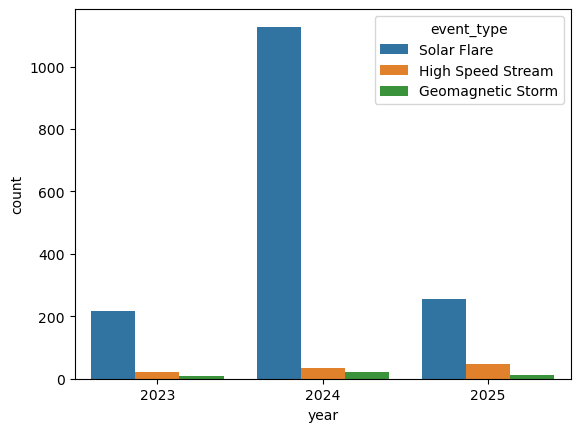

In [18]:
sns.countplot(x='year', hue='event_type', data=df)
plt.show()

## Monthly Distribution of Events

This analysis explores how space weather events are distributed across different months of the year.
It helps identify seasonal patterns in solar activity.

In [19]:
df.groupby('month')['event_type'].count()

month
1     118
2     135
3     118
4     119
5     234
6     104
7     167
8     196
9     140
10    132
11    133
12    147
Name: event_type, dtype: int64

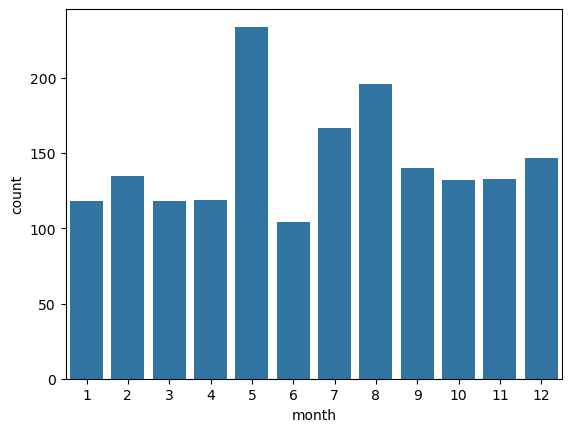

In [20]:
sns.countplot(x='month', data=df)
plt.show()

## Hour-wise Distribution of Events

This section analyzes how frequently space weather events occur during different hours of the day.

In [21]:
df.groupby('hour')['event_type'].count()

hour
0     74
1     64
2     68
3     84
4     73
5     69
6     78
7     64
8     79
9     73
10    62
11    71
12    92
13    65
14    69
15    76
16    70
17    62
18    69
19    78
20    75
21    81
22    76
23    71
Name: event_type, dtype: int64

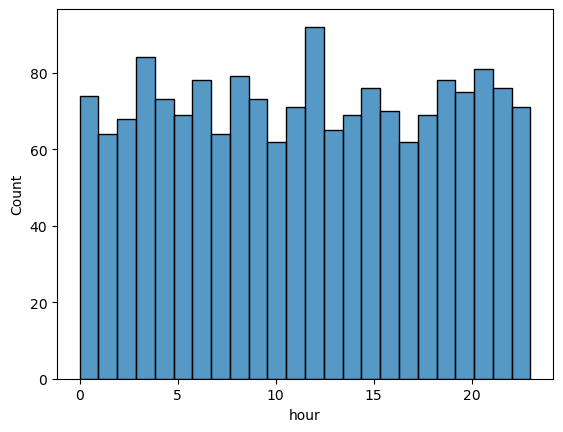

In [22]:
sns.histplot(df['hour'], bins=24)
plt.show()

## Solar Flare Class Analysis

Solar flares are categorized based on their intensity (e.g., B, C, M, X classes).  
This analysis examines the frequency of different solar flare classes in the dataset.

In [23]:
df['class_type'].value_counts()

class_type
M1.0       179
M1.1       128
M1.2       118
Unknown    103
M1.3        92
          ... 
X8.7         1
X3.4         1
X2.9         1
M9.3         1
M8.1         1
Name: count, Length: 188, dtype: int64

### Extracting Flare Categories

The first character of the flare class is extracted to categorize solar flares into major classes such as B, C, M, and X.

In [24]:
df['flare_class'] = df['class_type'].str[0]

### Solar Flare Class Distribution Plot

This visualization shows the distribution of solar flare categories and highlights which flare type occurs most frequently.

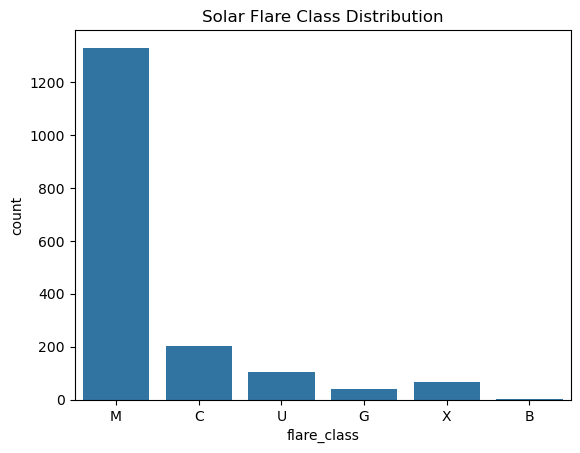

In [25]:
sns.countplot(x='flare_class', data=df)
plt.title("Solar Flare Class Distribution")
plt.show()

## Most Active Solar Regions

Solar activity often originates from specific active regions on the Sun.  
This analysis identifies the top regions responsible for the highest number of events.

In [26]:
df['active_region'].value_counts().head(10)

active_region
0        191
13664     90
13615     51
13663     42
13842     33
13697     33
13981     29
13738     26
13936     26
13883     25
Name: count, dtype: Int64

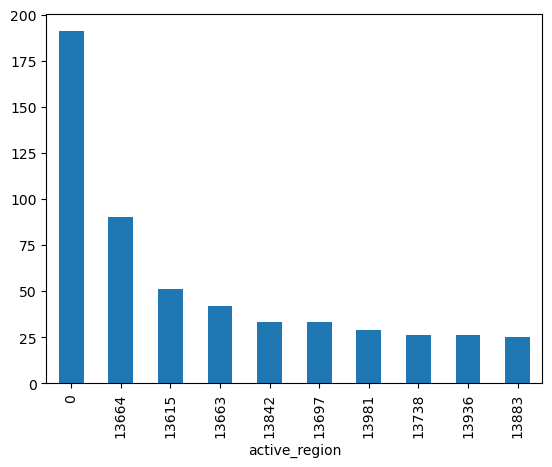

In [27]:
df['active_region'].value_counts().head(10).plot(kind='bar')
plt.show()

## Event Duration Analysis

The duration of each event is calculated as the difference between the event start time and end time.

This helps understand how long solar events typically last.

In [28]:
df['duration'] = df['end_time'] - df['begin_time']

In [29]:
df['duration'].describe()

count                         1599
mean     0 days 00:25:41.726078799
std      0 days 00:41:12.817128945
min              -1 days +02:00:00
25%                0 days 00:14:00
50%                0 days 00:20:00
75%                0 days 00:31:00
max                0 days 04:51:00
Name: duration, dtype: object

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables such as:

- active_region
- year
- month
- day
- hour

In [30]:
df.corr(numeric_only=True)

,active_region,year,month,day,hour
active_region,1.000000,-0.009465,0.052598,-0.018638,0.030628
year,-0.009465,1.000000,-0.530343,0.014428,-0.022662
month,0.052598,-0.530343,1.000000,-0.030011,0.010632
day,-0.018638,0.014428,-0.030011,1.000000,0.028069
hour,0.030628,-0.022662,0.010632,0.028069,1.000000


### Heatmap Visualization

A heatmap is used to visualize correlations between numerical features in the dataset.
This helps identify potential relationships between different variables.

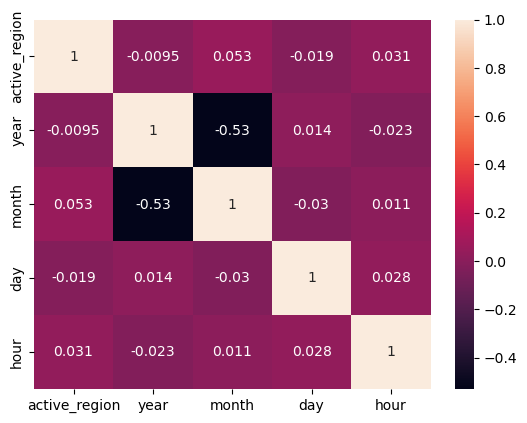

In [31]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Instruments Used for Detection

Different instruments are used to detect and record space weather events.  
This analysis shows which instruments are most frequently used in the dataset.

In [32]:
df['instruments'].value_counts().head(10)

instruments
GOES-P: EXIS 1.0-8.0                      1577
DSCOVR: PLASMAG, ACE: SWEPAM, ACE: MAG      49
Unknown                                     41
GOES-S: EXIS 1.0-8.0                        22
ACE: SWEPAM, ACE: MAG, DSCOVR: PLASMAG      20
STEREO A: IMPACT, STEREO A: PLASTIC         18
ACE: MAG, ACE: SWEPAM, DSCOVR: PLASMAG       5
STEREO A: PLASTIC, STEREO A: IMPACT          4
DSCOVR: PLASMAG                              3
STEREO A: IMPACT                             3
Name: count, dtype: int64

## Key Insights

Based on the exploratory data analysis, the following key observations were identified:

1. **Solar Flares dominate the dataset**
   - The majority of recorded space weather events are Solar Flares, while High Speed Streams and Geomagnetic Storms occur much less frequently.

2. **Solar activity peaked in 2024**
   - The year-wise analysis shows that the highest number of events occurred in 2024 compared to 2023 and 2025.

3. **Monthly variation in solar activity**
   - Certain months show a higher number of recorded events, indicating possible seasonal patterns in solar activity.

4. **Events occur throughout the day**
   - Hour-wise analysis shows that events are distributed across all hours, with some hours showing slightly higher activity.

5. **M-class solar flares are most common**
   - Solar flare classification analysis reveals that medium-intensity (M-class) flares appear most frequently in the dataset.

6. **Specific solar regions are more active**
   - Some solar active regions generate significantly more events than others, suggesting localized solar activity hotspots.

7. **Most events are detected by GOES instruments**
   - Instrument analysis shows that GOES-based instruments are responsible for detecting the majority of space weather events.

## Conclusion

This project analyzed space weather events using Python and SQL to explore patterns in solar activity.

Through data cleaning and exploratory data analysis, several trends were identified related to event frequency, flare intensity, time distribution, and active solar regions.

These insights help improve understanding of solar activity and demonstrate how data analysis techniques can be applied to scientific datasets.